<a href="https://colab.research.google.com/github/Sherlysukmadira/image_processing/blob/main/Normalisasi_Histogram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_463/1565905052.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])
/tmp/ipykernel_463/1565905052.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(normalized.ravel(),256,[0,256])


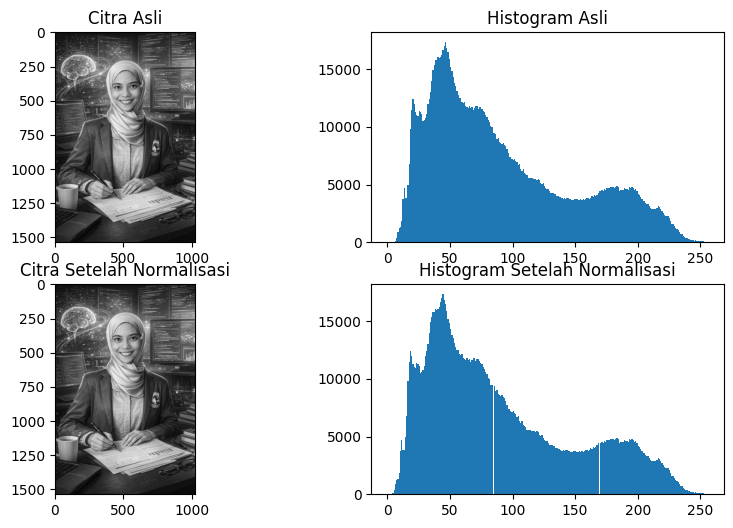

In [ ]:
#Tugas nomor 2 - normalisasi histogram
import cv2
import numpy as np
import matplotlib.pyplot as plt

# membaca gambar (grayscale)
img = cv2.imread('sherly ai.png', 0)

# mencari nilai minimum dan maksimum
Imin = np.min(img)
Imax = np.max(img)

# membuat array hasil
normalized = np.zeros(img.shape)

# proses normalisasi manual
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        normalized[i,j] = (img[i,j] - Imin) / (Imax - Imin) * 255

normalized = normalized.astype(np.uint8)

# menampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(221)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')

plt.subplot(222)
plt.title("Histogram Asli")
plt.hist(img.ravel(),256,[0,256])

plt.subplot(223)
plt.title("Citra Setelah Normalisasi")
plt.imshow(normalized, cmap='gray')

plt.subplot(224)
plt.title("Histogram Setelah Normalisasi")
plt.hist(normalized.ravel(),256,[0,256])

plt.show()

Dapat dilihat bahwa citra asli lebih gelap sementara citra setelah dinormalisasi lebih cerah, kemudian histogram lebih rengang atau lebih melebar

/tmp/ipykernel_463/4162428013.py:44: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])
/tmp/ipykernel_463/4162428013.py:52: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(),256,[0,256])


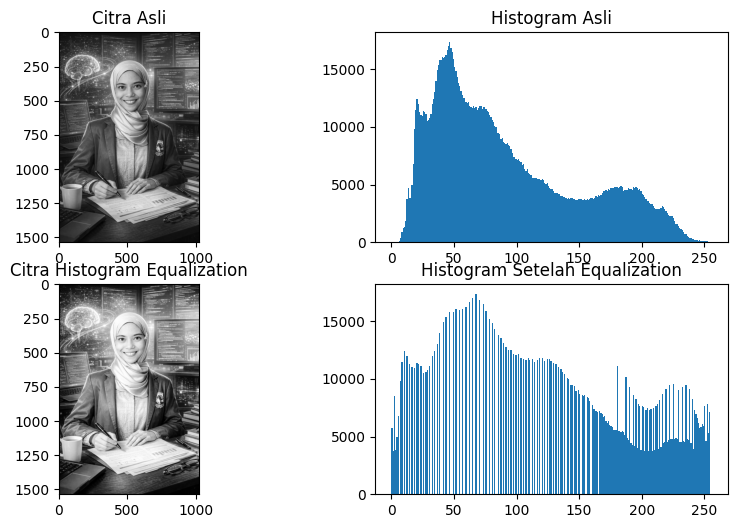

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# membaca gambar
img = cv2.imread('sherly ai.png',0)

# menghitung histogram manual
hist = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i,j]] += 1

# menghitung CDF
cdf = np.zeros(256)
cdf[0] = hist[0]

for i in range(1,256):
    cdf[i] = cdf[i-1] + hist[i]

# normalisasi CDF
cdf_normalized = (cdf - np.min(cdf)) / (np.max(cdf) - np.min(cdf)) * 255
cdf_normalized = cdf_normalized.astype(np.uint8)

# membuat citra hasil
equalized = np.zeros(img.shape)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        equalized[i,j] = cdf_normalized[img[i,j]]

equalized = equalized.astype(np.uint8)

# menampilkan hasil
plt.figure(figsize=(10,6))

plt.subplot(221)
plt.title("Citra Asli")
plt.imshow(img, cmap='gray')

plt.subplot(222)
plt.title("Histogram Asli")
plt.hist(img.ravel(),256,[0,256])

plt.subplot(223)
plt.title("Citra Histogram Equalization")
plt.imshow(equalized, cmap='gray')

plt.subplot(224)
plt.title("Histogram Setelah Equalization")
plt.hist(equalized.ravel(),256,[0,256])

plt.show()

Dapat dilihat bahwa citra asli lebih gelap sementara citra setelah dinormalisasi lebih cerah, kemudian histogram lebih merata atau tersebar

Insight :
Normalisasi berfungsi untuk Meregangkan rentang intensitas sementara Equalization berfungsi untuk meratakan distribusi histogram